In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

In [15]:
df=pd.read_table('Fig1c.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
0,8241,Liarum,Sweden,55.9473,13.8210,CS77038,leaf,Sweden_leaf,6425.217028,6.800000,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6203,TDr-18,Sweden,55.7714,14.1208,CS77350,leaf,Sweden_leaf,6106.090545,7.400000,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5984,DraIV 6-13,Czech Republic,49.4112,16.2815,CS76822,leaf,Czech Republic_leaf,5937.667641,7.395833,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,9399,Hamm-1,Sweden,55.4234,13.9905,CS76910,leaf,Sweden_leaf,5936.194976,7.937500,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,8420,Kelsterbach-4,GER,50.0667,8.5333,CS76525,leaf,GER_leaf,5842.619693,10.337500,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [16]:
df=df.rename(columns={'coarse_frag':'coarse frag',
                   'bulk_density':'bulk density',
                   'CaCO3':'CaCO$_3$',
                     'ph':'pH',
                     'ai':'AI',
                     'awc':'AWC'})

In [17]:
df=df.select_dtypes(include='number')
df=df.drop(columns=['Accession_ID','Latitude','Longitude'])
df.head()

,Mg25,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
0,6425.217028,6.800000,7.100000,29.831934,632.671082,20.400000,-3.4,23.799999,3.716667,5.483333,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6106.090545,7.400000,6.966667,29.645391,620.901123,21.000000,-2.5,23.500000,4.400000,2.383333,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5937.667641,7.395833,8.241667,30.079075,733.808411,22.500000,-4.9,27.400000,16.350000,-0.300000,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,5936.194976,7.937500,6.741666,28.566383,631.276184,21.299999,-2.3,23.599998,8.766666,2.783333,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,5842.619693,10.337500,8.458333,32.532051,672.647827,25.100000,-0.9,26.000000,17.166666,6.133333,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [139]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [140]:
# Splitting the dataset into training and testing set (80/20)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 42)


In [141]:
model = RandomForestRegressor(max_depth=5, random_state=42,max_features='auto',max_leaf_nodes=10,n_estimators=100)
model.fit(x_train, y_train.values.ravel())

RandomForestRegressor(max_depth=5, max_leaf_nodes=10, random_state=42)

In [142]:
y_pred=model.predict(x_test)

In [143]:
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 312.85
Mean Squared Error: 161535.87
R-squared scores: 0.22


In [144]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':[5],
           'max_leaf_nodes':[10],
           'n_estimators':[100]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=5)
forest_model_cv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=0),
             param_grid={'max_depth': [5], 'max_leaf_nodes': [10],
                         'n_estimators': [100]})

In [145]:
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)
# print('R2 training set:',round(r2_score(y_train,forest_model_cv.predict(x_train)),2))

{'max_depth': 5, 'max_leaf_nodes': 10, 'n_estimators': 100}
0.15930212408236075


In [23]:
round(r2_score(y_train.values.ravel(), model.predict(x_train)),2)

0.38

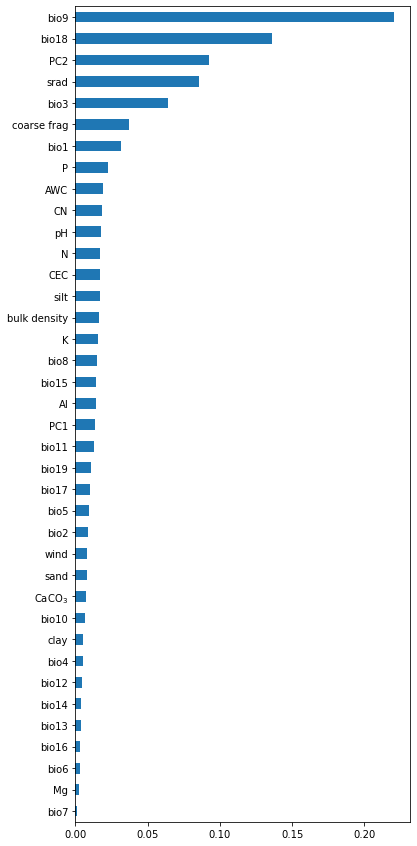

In [24]:
model_ranks=pd.Series(model.feature_importances_,index=x_train.columns).sort_values()
fig, ax = plt.subplots(figsize=(6,15))
ax=model_ranks.plot(kind='barh')


In [25]:
importances = model.feature_importances_
std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)

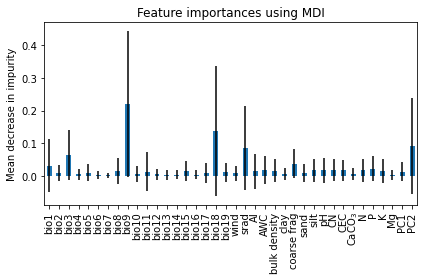

In [26]:
model_importances = pd.Series(importances, index=x_train.columns)

fig, ax = plt.subplots()
model_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [29]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, x_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=x_train.columns)

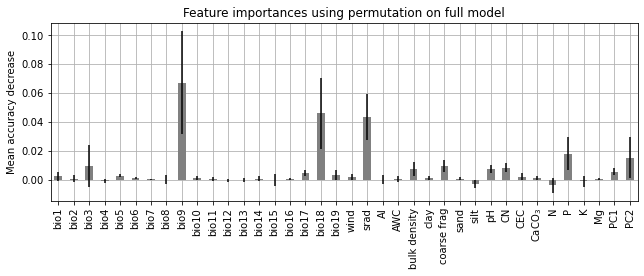

In [30]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [33]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, x_test, y_test, n_repeats=1000, random_state=42, n_jobs=2
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=x_train.columns)

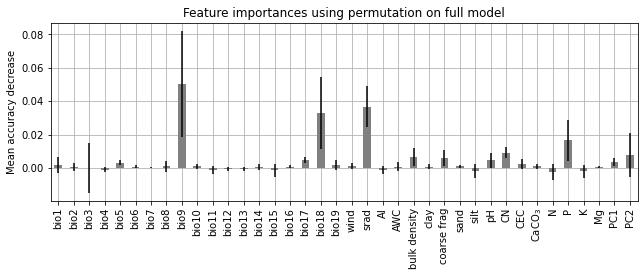

In [32]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [146]:
test=df.drop(columns=['bio9','bio18'])
test.head()

,Mg25,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
0,6425.22,6.80,7.10,29.83,632.67,20.40,-3.40,23.80,3.72,14.87,...,5.10,16.02,11.40,9.00,2.90,34.88,99.04,37,-0.02,-0.02
1,6106.09,7.40,6.97,29.65,620.90,21.00,-2.50,23.50,4.40,15.38,...,5.31,16.93,11.27,11.34,2.78,43.92,128.46,40,-0.01,-0.03
2,5937.67,7.40,8.24,30.08,733.81,22.50,-4.90,27.40,16.35,16.35,...,5.72,10.38,11.53,0.00,2.13,38.88,205.52,47,-0.05,-0.00
3,5936.19,7.94,6.74,28.57,631.28,21.30,-2.30,23.60,8.77,15.97,...,6.32,11.38,13.25,10.35,2.15,56.95,138.10,39,-0.01,-0.03
4,5842.62,10.34,8.46,32.53,672.65,25.10,-0.90,26.00,17.17,18.82,...,6.73,13.34,11.84,54.42,1.57,32.80,158.97,43,-0.03,0.00


In [147]:
X=test.drop(columns=['Mg25'])
y=test['Mg25']

In [148]:
# Splitting the dataset into training and testing set (80/20)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 42)


In [149]:
model = RandomForestRegressor(max_depth=5, random_state=42,max_features='auto',max_leaf_nodes=10,n_estimators=100)
model.fit(x_train, y_train.values.ravel())

RandomForestRegressor(max_depth=5, max_leaf_nodes=10, random_state=42)

In [150]:
y_pred=model.predict(x_test)

In [151]:
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 315.35
Mean Squared Error: 160974.93
R-squared scores: 0.23


In [152]:
round(r2_score(y_train.values.ravel(), model.predict(x_train)),2)

0.38

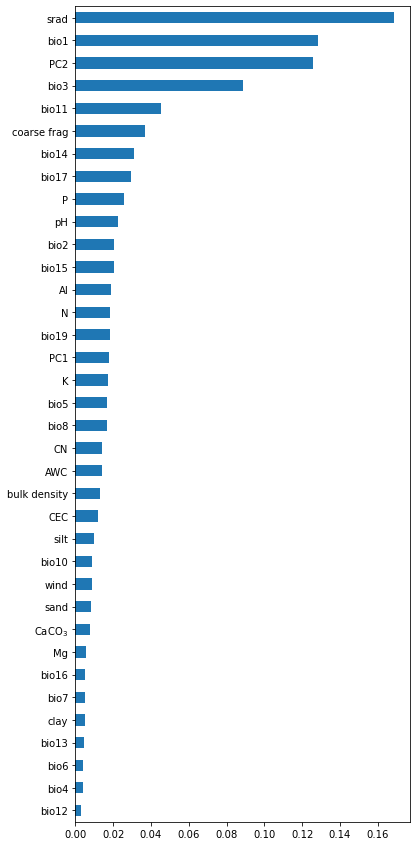

In [114]:
model_ranks=pd.Series(model.feature_importances_,index=x_train.columns).sort_values()
fig, ax = plt.subplots(figsize=(6,15))
ax=model_ranks.plot(kind='barh')


In [115]:
importances = model.feature_importances_
std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)

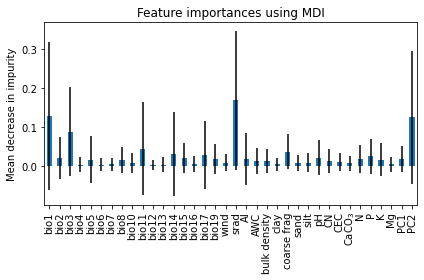

In [116]:
model_importances = pd.Series(importances, index=x_train.columns)

fig, ax = plt.subplots()
model_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [117]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, x_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=x_train.columns)

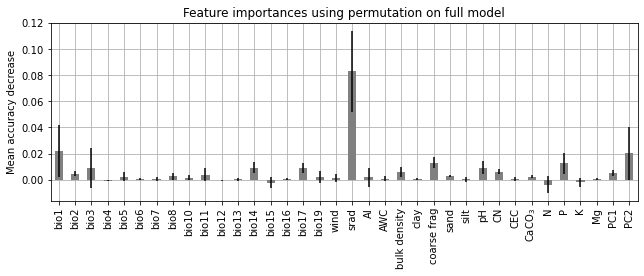

In [118]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [153]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':[5],
           'max_leaf_nodes':[10],
           'n_estimators':[100]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=5)
forest_model_cv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=0),
             param_grid={'max_depth': [5], 'max_leaf_nodes': [10],
                         'n_estimators': [100]})

In [154]:
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)
# print('R2 training set:',round(r2_score(y_train,forest_model_cv.predict(x_train)),2))

{'max_depth': 5, 'max_leaf_nodes': 10, 'n_estimators': 100}
0.15396278355946535


In [107]:
Y_pred=forest_model_cv.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 315.35
Mean Squared Error: 160974.93
R-squared scores: 0.23


In [119]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, x_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=x_train.columns)

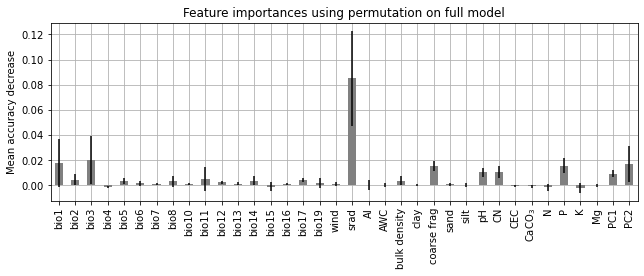

In [120]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [136]:
X.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
0,6.80,7.10,29.83,632.67,20.40,-3.40,23.80,3.72,5.48,14.87,...,5.10,16.02,11.40,9.00,2.90,34.88,99.04,37,-0.02,-0.02
1,7.40,6.97,29.65,620.90,21.00,-2.50,23.50,4.40,2.38,15.38,...,5.31,16.93,11.27,11.34,2.78,43.92,128.46,40,-0.01,-0.03
2,7.40,8.24,30.08,733.81,22.50,-4.90,27.40,16.35,-0.30,16.35,...,5.72,10.38,11.53,0.00,2.13,38.88,205.52,47,-0.05,-0.00
3,7.94,6.74,28.57,631.28,21.30,-2.30,23.60,8.77,2.78,15.97,...,6.32,11.38,13.25,10.35,2.15,56.95,138.10,39,-0.01,-0.03
4,10.34,8.46,32.53,672.65,25.10,-0.90,26.00,17.17,6.13,18.82,...,6.73,13.34,11.84,54.42,1.57,32.80,158.97,43,-0.03,0.00


In [132]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
VIF = pd.DataFrame()
VIF['feature'] = X.columns
VIF['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [133]:
VIF.sort_values(by=['VIF'],ascending=False,key=abs)

,feature,VIF
4,bio5,2251799813685248.00
6,bio7,2251799813685248.00
5,bio6,52367437527563.91
9,bio10,194368.02
3,bio4,103950.32
0,bio1,15617.11
1,bio2,11555.74
2,bio3,9821.47
10,bio11,6462.57
26,sand,3906.78


In [129]:
pd.options.display.float_format = '{:.2f}'.format